In [20]:
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt


config_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/"
if config_dir not in sys.path:
    sys.path.append(config_dir)
import config


In [13]:
def compile_experiment_results(folder_path):
    """
    Reads all cluster pickles and maps metadata from config.py.
    """
    # 1. Grab all pkl files in the folder
    search_pattern = os.path.join(folder_path, "*.pkl")
    all_files = glob.glob(search_pattern)
    
    master_list = []

    for file in all_files:
        # Load the individual experiment results
        df = pd.read_pickle(file)
        
        # 2. Extract numeric ID (e.g., 'c1' from 'c1_df_clusters.pkl')
        filename = os.path.basename(file)
        cell_id_str = filename.split('_')[0] 
        cell_id_num = int(cell_id_str.replace('c', ''))
        
        # Add basic identifiers
        df['cell_id'] = cell_id_str
        
        # 3. Map metadata from config.py dictionaries
        # Use .get() to avoid errors if a cell_id is missing in config
        patch_info = config.DICT_PATCH_TYPE.get(cell_id_num, "Unknown, Unknown")
        
        # Split "Juxta, IC" into two distinct columns for your table
        df['patch_type'], df['current_type'] = patch_info.split(', ')
        
        df['cell_type'] = config.DICT_CELL_TYPE.get(cell_id_num)
        df['cortical_depth'] = config.DICT_CORT_DEPTH.get(cell_id_num)
        df['dark_neuron'] = config.DICT_DARK_NEURONS.get(cell_id_num)
        df['clear_EAP_waveform'] = config.DICT_CLEAR_EAP_WAV.get(cell_id_num)
        
        master_list.append(df)

    # 4. Concatenate and Reorder
    final_table = pd.concat(master_list, ignore_index=True)
    
    # Rename for clarity to match your whiteboard
    final_table = final_table.rename(columns={
        'feature_clustered': 'spike_feature',
        'groups': 'cluster'
    })

    # Order columns as requested
    cols = [
        'cell_id', 'spike_feature', 'cluster', 'nRMSE', 'cos_sim',
        'patch_type', 'current_type', 'cell_type', 'cortical_depth', 
        'dark_neuron', 'clear_EAP_waveform'
    ]
    
    return final_table[cols]



In [14]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles"

In [17]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [18]:
df_master

,cell_id,spike_feature,cluster,nRMSE,cos_sim,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform
0,c34,log_isi,Low-High,0.009285,0.999733,Juxta,IC,PC,1454.4,False,False
1,c4,inflection_time,Low-High,0.085968,0.992827,WC,IC,PC,836.7,False,True
2,c4,peak_amp,Low-High,0.107073,0.987907,WC,IC,PC,836.7,False,True
3,c4,spk_times_ms,Low-High,0.102381,0.989149,WC,IC,PC,836.7,False,True
4,c10,peak_amp,Low-Mid,0.066243,0.955793,Juxta,VC,PC,718.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
114,c1,peak_sharpness,Low-High,0.089557,0.994296,Juxta,IC,PC,843.9,False,False
115,c1,exp_lambda,Low-High,0.057307,0.991058,Juxta,IC,PC,843.9,False,False
116,c1,log_isi,Low-Mid,0.042693,0.998962,Juxta,IC,PC,843.9,False,False
117,c1,log_isi,Low-High,0.039721,0.999174,Juxta,IC,PC,843.9,False,False


In [31]:


def save_clean_merged_table(df, filename='final_merged_report.png'):
    # 1. Formatting and Prep
    cols_order = [
        'cell_id', 'patch_type', 'current_type', 'cell_type', 'cortical_depth', 
        'dark_neuron', 'clear_EAP_waveform', 'spike_feature', 'cluster', 'nRMSE', 'cos_sim'
    ]
    plot_data = df[cols_order].copy()
    
    # Apply formatting from your config and whiteboard requirements
    plot_data['nRMSE'] = plot_data['nRMSE'].map(lambda x: f'{x:.3f}' if isinstance(x, float) else x)
    plot_data['cos_sim'] = plot_data['cos_sim'].map(lambda x: f'{x:.3f}' if isinstance(x, float) else x)
    plot_data['cortical_depth'] = plot_data['cortical_depth'].map(lambda x: f'{x:.1f}' if isinstance(x, float) else x)
    
    # 2. Setup Figure
    fig_height = len(plot_data) * 0.6 + 2
    fig, ax = plt.subplots(figsize=(22, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=plot_data.values,
        colLabels=[c.replace('_', ' ').title() for c in plot_data.columns],
        cellLoc='center',
        loc='center'
    )

    # 3. True Merging Logic
    def merge_cells(table, row_start, row_end, col):
        """Physically merges cells from row_start to row_end in a specific column."""
        main_cell = table[row_start, col]
        for row in range(row_start + 1, row_end + 1):
            cell = table[row, col]
            cell.get_text().set_text("")
            cell.visible_edges = 'LR' # Only side edges for internal rows
        
        table[row_end, col].visible_edges = 'LRB' # Bottom edge for the end of the block
        main_cell.visible_edges = 'LRT' # Top edge for the start of the block
        
        # Force vertical centering within the spanned area
        main_cell.get_text().set_verticalalignment('center')

    # Logic to identify blocks based on your experimental groups
    start_row = 1 
    for i in range(1, len(plot_data) + 1):
        if i == len(plot_data) or plot_data.iloc[i]['cell_id'] != plot_data.iloc[start_row-1]['cell_id']:
            end_row = i
            # Merge Cell Metadata columns (0 through 6)
            for c in range(7):
                merge_cells(table, start_row, end_row, c)
            
            # Merge Spike Features within the Cell block
            feat_start = start_row
            for j in range(start_row, end_row + 1):
                current_feat = plot_data.iloc[j-1]['spike_feature']
                next_feat = plot_data.iloc[j]['spike_feature'] if j < end_row else None
                
                if next_feat != current_feat:
                    merge_cells(table, feat_start, j, 7)
                    feat_start = j + 1
            
            start_row = i + 1

    # 4. Styling & Error Fix
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 3.5) 

    header_color = '#40466e'
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#BDBDBD')
        # Fix alignment for ALL cells
        cell.get_text().set_verticalalignment('center')
        
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(header_color)
            cell.visible_edges = 'closed' # FIX: Use 'closed' instead of '1'
        elif col >= 9:
            cell.set_facecolor('#F8F9FA')

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()



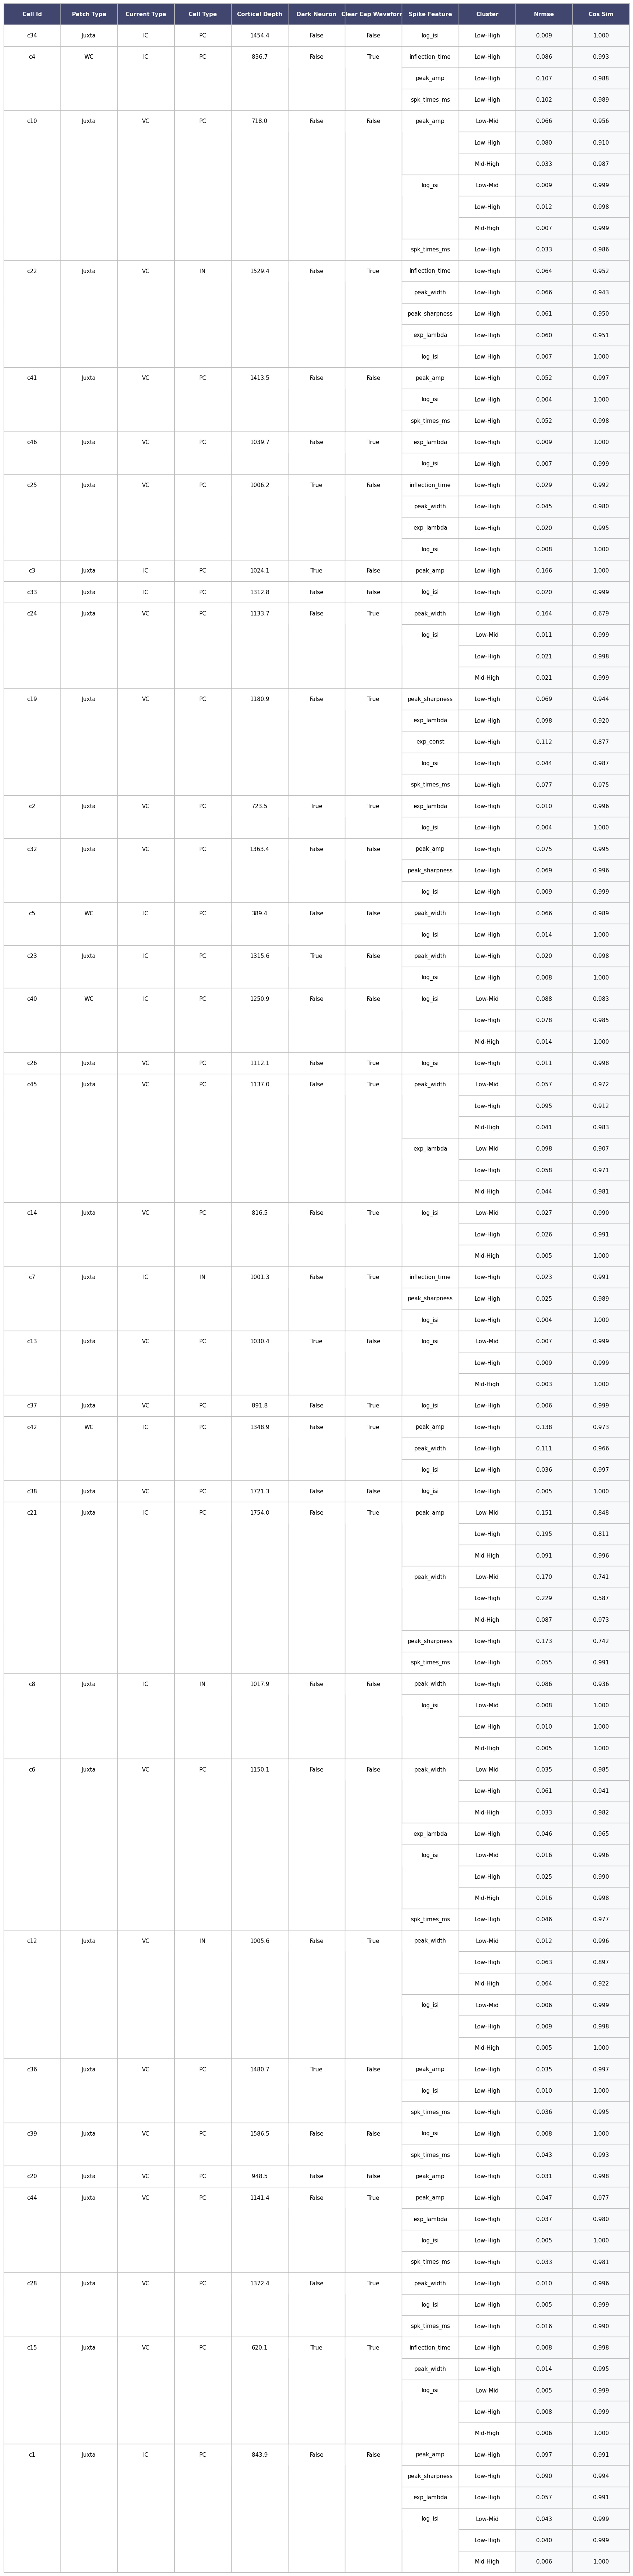

In [32]:
save_clean_merged_table(df_master)